# Informasi Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
df = pd.read_csv('US_Accidents_Cleaned.csv')

In [3]:
thresholds = {
    'Temperature(F)': (-42, 123),
    'Humidity(%)': (5, 100),
    'Pressure(in)': (22.1, 31.1),
    'Visibility(mi)': (0, 10),
    'Wind_Speed(mph)': (0, 23),
    'Precipitation(in)': (0, 2),
    'Distance(mi)' : (0, 300),
    'Duration' : (0, 3000) # 2 hari
}

results = []

# 2. Iterasi untuk mengecek per kolom
for col, (low, high) in thresholds.items():
    if col in df.columns:
        # Menghitung data yang di luar rentang DAN bukan NaN
        outliers_count = df[
            (df[col].notna()) & 
            ((df[col] < low) | (df[col] > high))
        ].shape[0]
        
        results.append({
            'Kolom': col,
            'Rentang Normal': f"{low} s/d {high}",
            'Jumlah Outlier': outliers_count
        })

# 3. Tampilkan dalam DataFrame agar rapi
df_outliers = pd.DataFrame(results)
print(df_outliers.to_markdown(index=False))

| Kolom             | Rentang Normal   |   Jumlah Outlier |
|:------------------|:-----------------|-----------------:|
| Temperature(F)    | -42 s/d 123      |                0 |
| Humidity(%)       | 5 s/d 100        |                0 |
| Pressure(in)      | 22.1 s/d 31.1    |                0 |
| Visibility(mi)    | 0 s/d 10         |                0 |
| Wind_Speed(mph)   | 0 s/d 23         |                0 |
| Precipitation(in) | 0 s/d 2          |                0 |
| Distance(mi)      | 0 s/d 300        |                0 |
| Duration          | 0 s/d 3000       |                0 |


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178913 entries, 0 to 1178912
Data columns (total 33 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Severity               1178913 non-null  int64  
 1   Start_Time             1178913 non-null  object 
 2   End_Time               1178913 non-null  object 
 3   Distance(mi)           1178913 non-null  float64
 4   City                   1178913 non-null  object 
 5   County                 1178913 non-null  object 
 6   State                  1178913 non-null  object 
 7   Temperature(F)         1178913 non-null  float64
 8   Humidity(%)            1178913 non-null  float64
 9   Pressure(in)           1178913 non-null  float64
 10  Visibility(mi)         1178913 non-null  float64
 11  Wind_Direction         1178913 non-null  object 
 12  Wind_Speed(mph)        1178913 non-null  float64
 13  Precipitation(in)      1178913 non-null  float64
 14  Weather_Condition 

In [7]:
df.isnull().sum()

Severity                 0
Start_Time               0
End_Time                 0
Distance(mi)             0
City                     0
County                   0
State                    0
Temperature(F)           0
Humidity(%)              0
Pressure(in)             0
Visibility(mi)           0
Wind_Direction           0
Wind_Speed(mph)          0
Precipitation(in)        0
Weather_Condition        0
Amenity                  0
Bump                     0
Crossing                 0
Give_Way                 0
Junction                 0
No_Exit                  0
Railway                  0
Roundabout               0
Station                  0
Stop                     0
Traffic_Calming          0
Traffic_Signal           0
Astronomical_Twilight    0
Duration                 0
Hour                     0
Month                    0
Day                      0
Road_Features            0
dtype: int64

## Daftar Kolom

In [8]:
df.columns

Index(['Severity', 'Start_Time', 'End_Time', 'Distance(mi)', 'City', 'County',
       'State', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
       'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Astronomical_Twilight',
       'Duration', 'Hour', 'Month', 'Day', 'Road_Features'],
      dtype='object')

## Memisahkan Kolom Numerical dan Kategorikal

In [4]:
# 1. Daftar Kolom Numerik (Data yang berupa angka kontinu/ukur)
numerical_cols = [
    'Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Duration'
]

# 2. Daftar Kolom Kategorikal (Data label, lokasi, waktu, dan fitur jalan)
categorical_cols = [
    'Severity', 'City', 'County', 'State', 'Wind_Direction', 
    'Weather_Condition', 'Astronomical_Twilight', 'Hour', 'Month', 'Day',
    # Fitur Jalan (Boolean/Binary)
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 
    'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 
    'Traffic_Signal', 'Road_Features'
]

# 3. Kolom Datetime (Jika kamu masih butuh referensi waktu asli)
datetime_cols = ['Start_Time', 'End_Time']

# Opsional: Cek apakah ada kolom yang tertinggal
all_cols = numerical_cols + categorical_cols + datetime_cols
missing = [col for col in df.columns if col not in all_cols]

print(f"Jumlah Kolom Numerik: {len(numerical_cols)}")
print(f"Jumlah Kolom Kategorikal: {len(categorical_cols)}")
if missing:
    print(f"Kolom yang belum terklasifikasi: {missing}")

Jumlah Kolom Numerik: 8
Jumlah Kolom Kategorikal: 23


## Distribusi Kolom Numerical

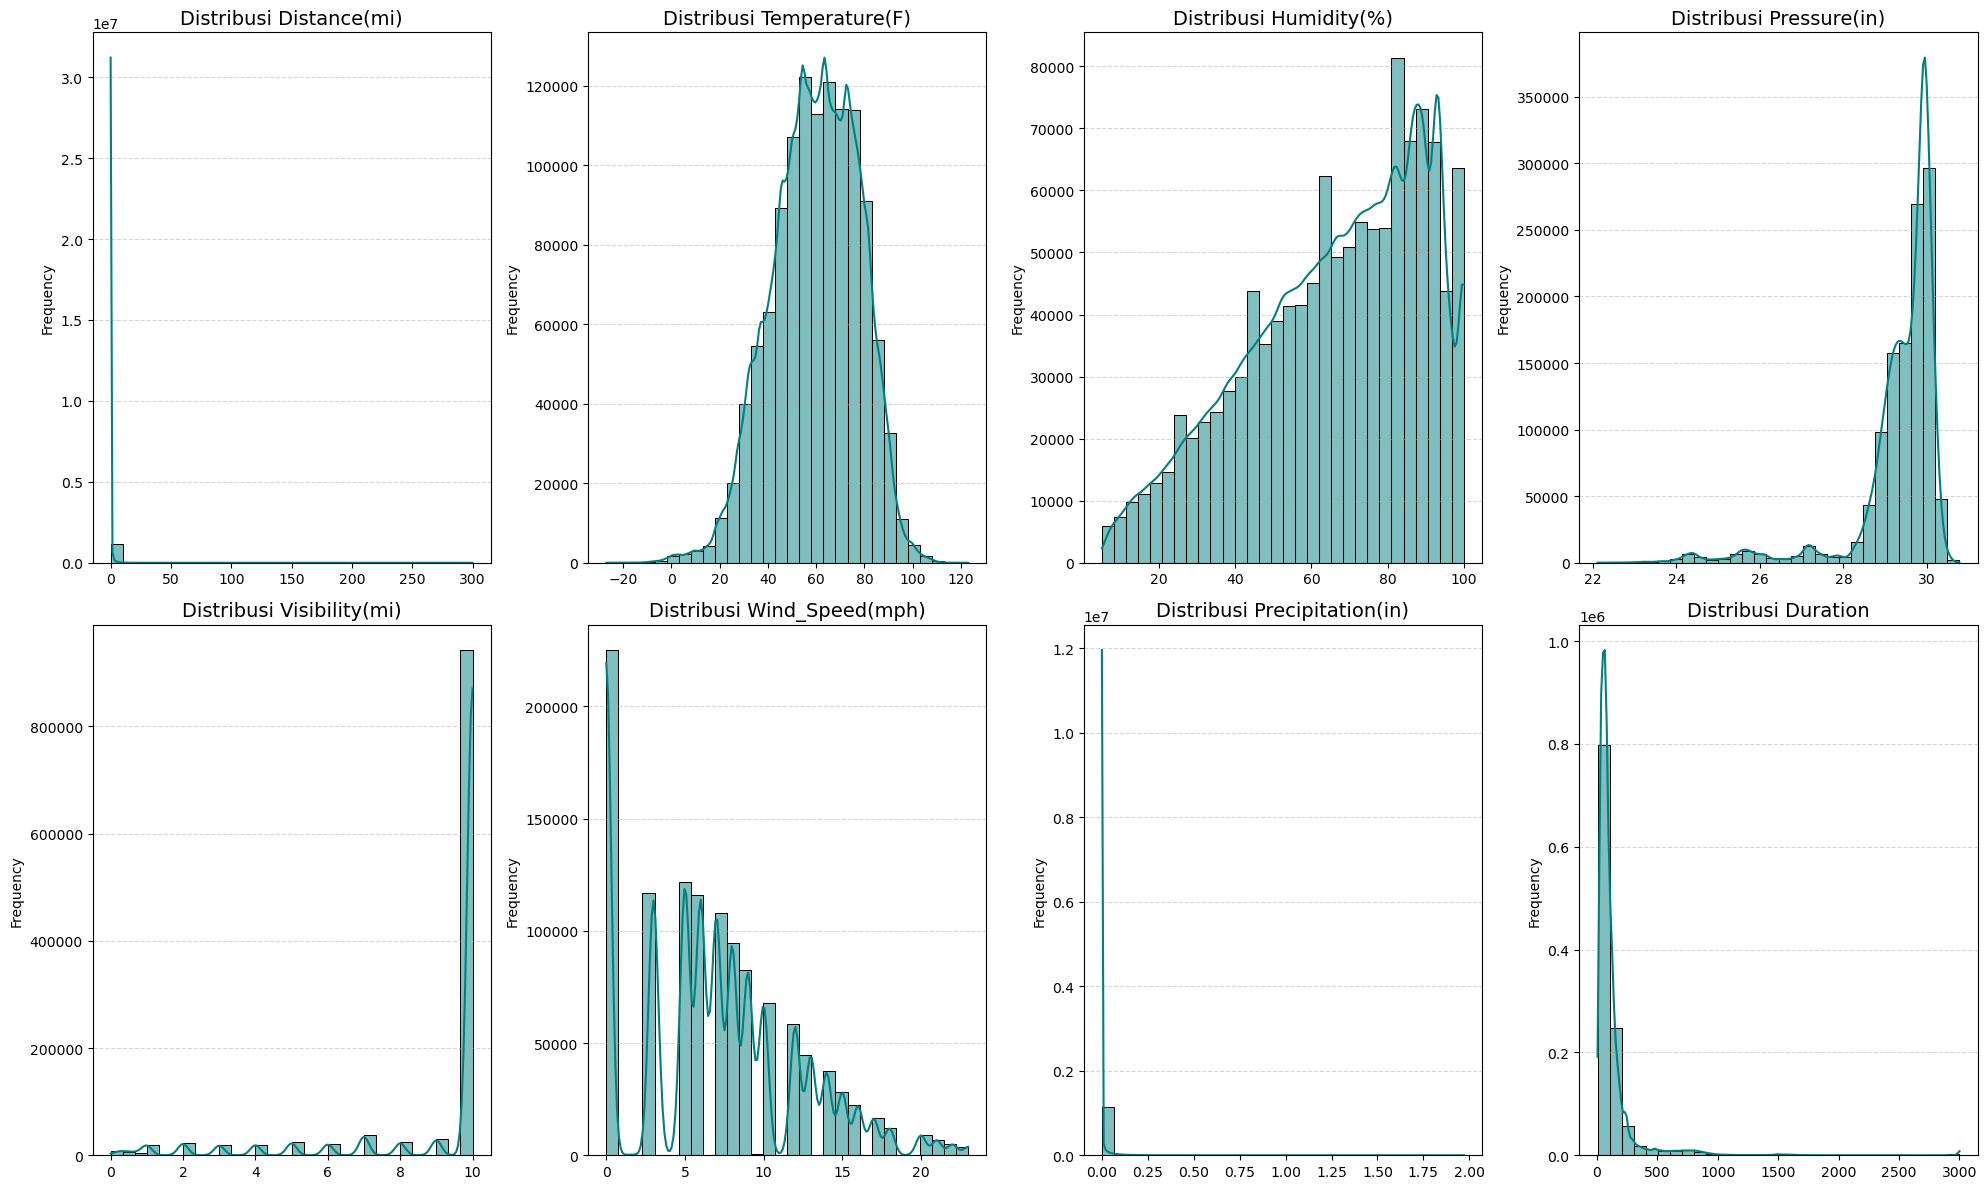

In [10]:
n_cols = 4
n_rows = 2

plt.figure(figsize=(20, 6 * n_rows))

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Plot histogram dengan kurva KDE
    sns.histplot(df[col], kde=True, color="teal", bins=30)
    
    plt.title(f"Distribusi {col}", fontsize=14)
    plt.xlabel("")
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## To Do List
- Melakukan log transform pada kolom Distance, Precipitation, Duration
- Binning se bisa mungkin
- Encoding kolom yang bentuk teks
- Menangani imbalaced distribution data

# Feature Engineering

In [11]:
df.columns

Index(['Severity', 'Start_Time', 'End_Time', 'Distance(mi)', 'City', 'County',
       'State', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
       'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Astronomical_Twilight',
       'Duration', 'Hour', 'Month', 'Day', 'Road_Features'],
      dtype='object')

## Membuat Kolom Weekend

In [5]:
df['Is_Weekend'] = df['Day'].apply(lambda x: 1 if x >= 5 else 0)

## Membuat Kolom Apakah Hujan?
Bernilai 1 jika hujan

In [6]:
df['Is_Precipitating'] = df['Precipitation(in)'] > 0

# Mengubah Tipe Data

In [7]:
df = df.drop(columns=['Start_Time', 'End_Time'])

In [8]:
numerical_cols = [
    'Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Duration'
]

# 2. Daftar Kolom Kategorikal (Data label, lokasi, waktu, dan fitur jalan)
categorical_cols = [
    'Severity', 'City', 'County', 'State', 'Wind_Direction',
    'Weather_Condition', 'Month', 'Day', 'Hour', 'Time_Period',
    'Temp_Category', 'Distance_Category', 'Duration_Category', 
    'Road_Features', 
]

boolean_cols = ['Astronomical_Twilight', 'Amenity', 'Bump', 'Crossing', 
                'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 
                'Station', 'Stop', 'Traffic_Calming','Traffic_Signal', 
                'Is_Weekend', 'Is_Precipitating'] 

all_classified_cols = numerical_cols + categorical_cols + boolean_cols 

# Cek kolom yang tertinggal di DataFrame (df)
missing = [col for col in df.columns if col not in all_classified_cols]

print(f"✅ Jumlah Kolom Numerik     : {len(numerical_cols)}")
print(f"✅ Jumlah Kolom Kategorikal : {len(categorical_cols)}")
print(f"✅ Jumlah Kolom Boolean     : {len(boolean_cols)}")

if missing:
    print(f"⚠️ Kolom belum terklasifikasi ({len(missing)}): {missing}")
else:
    print("🚀 Semua kolom telah terklasifikasi dengan benar!")

✅ Jumlah Kolom Numerik     : 8
✅ Jumlah Kolom Kategorikal : 14
✅ Jumlah Kolom Boolean     : 15
🚀 Semua kolom telah terklasifikasi dengan benar!


In [8]:
mapping = {'Day': True, 'Night': False}

df['Astronomical_Twilight'] = df['Astronomical_Twilight'].map(mapping).astype('bool')

print("\n--- Hasil Konversi ---")
print(df['Astronomical_Twilight'].value_counts())
print(f"Tipe data sekarang: {df['Astronomical_Twilight'].dtype}")


--- Hasil Konversi ---
Astronomical_Twilight
True     860167
False    318746
Name: count, dtype: int64
Tipe data sekarang: bool


In [9]:
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

for col in boolean_cols:
    if col in df.columns:
        df[col] = df[col].astype(bool)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178913 entries, 0 to 1178912
Data columns (total 33 columns):
 #   Column                 Non-Null Count    Dtype   
---  ------                 --------------    -----   
 0   Severity               1178913 non-null  category
 1   Distance(mi)           1178913 non-null  float64 
 2   City                   1178913 non-null  category
 3   County                 1178913 non-null  category
 4   State                  1178913 non-null  category
 5   Temperature(F)         1178913 non-null  float64 
 6   Humidity(%)            1178913 non-null  float64 
 7   Pressure(in)           1178913 non-null  float64 
 8   Visibility(mi)         1178913 non-null  float64 
 9   Wind_Direction         1178913 non-null  category
 10  Wind_Speed(mph)        1178913 non-null  float64 
 11  Precipitation(in)      1178913 non-null  float64 
 12  Weather_Condition      1178913 non-null  category
 13  Amenity                1178913 non-null  bool    
 14  Bu

# Log Transform

In [10]:
cols_to_transform = ['Distance(mi)', 'Precipitation(in)', 'Duration']

for col in cols_to_transform:
    df[col] = df[col].fillna(0)

for col in cols_to_transform:
    df[f'Log_{col}'] = np.log1p(df[col])

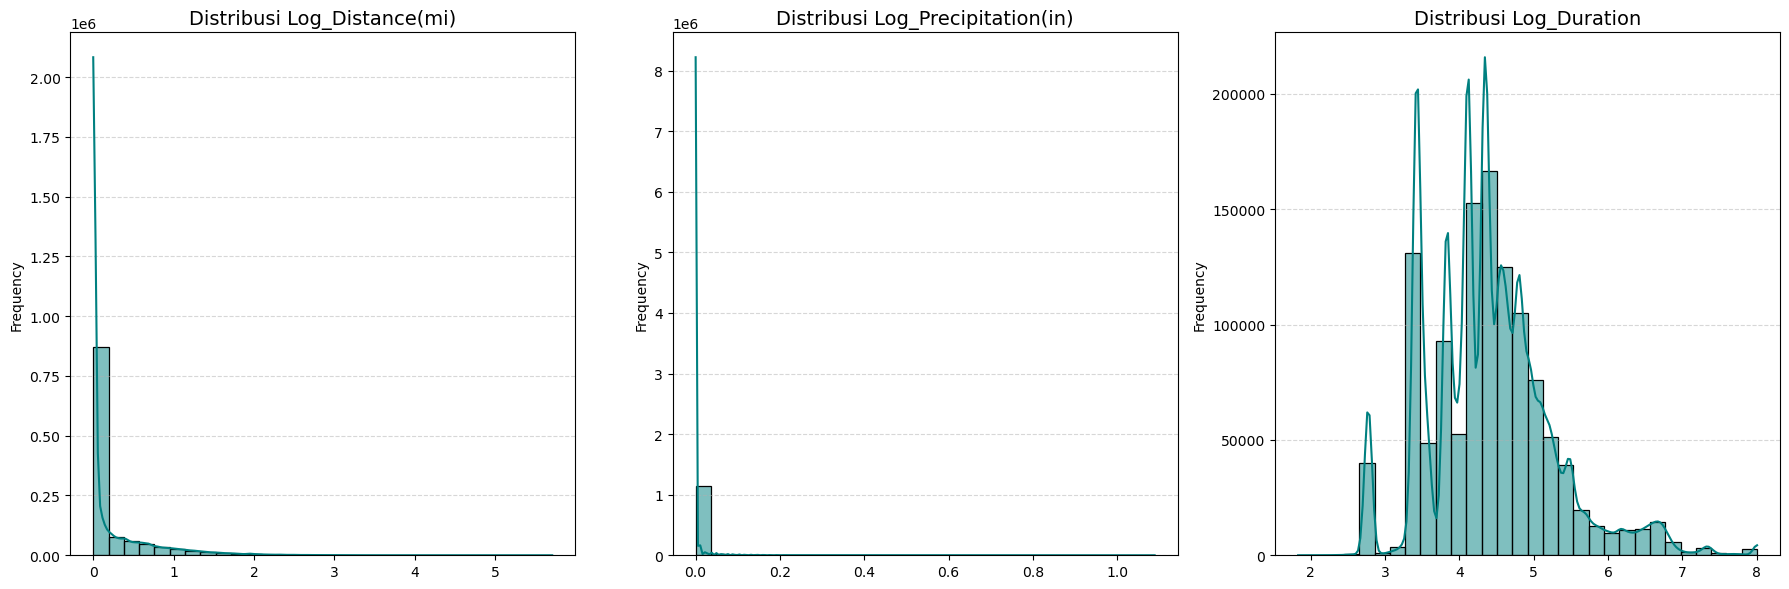

In [11]:
log_columns = ['Log_Distance(mi)', 'Log_Precipitation(in)', 'Log_Duration']

n_cols = 3
n_rows = 1

plt.figure(figsize=(18, 6 * n_rows))

for i, col in enumerate(log_columns):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Plot histogram dengan kurva KDE
    sns.histplot(df[col], kde=True, color="teal", bins=30)
    
    plt.title(f"Distribusi {col}", fontsize=14)
    plt.xlabel("")
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
df = df.drop(columns=['Distance(mi)', 'Precipitation(in)', 'Duration'])

# Binning

## Hour

In [12]:
bins = [0, 5, 9, 15, 19, 23]
labels = ['Late Night', 'Morning Rush', 'Office Hours', 'Evening Rush', 'Night']

df['Time_Period'] = pd.cut(df['Hour'], bins=bins, labels=labels, include_lowest=True)

## Temperature

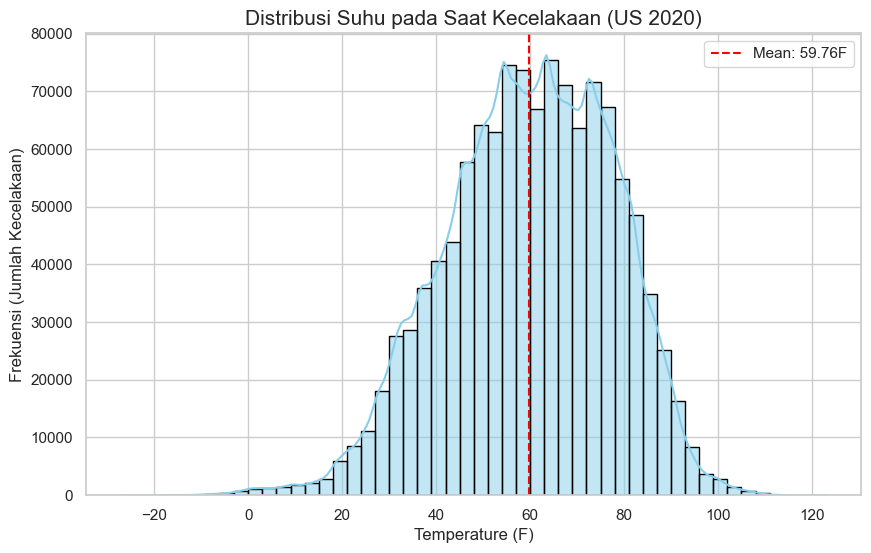

In [13]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Membuat histogram untuk Temperature(F)
sns.histplot(df['Temperature(F)'], kde=True, bins=50, color='skyblue', edgecolor='black')

# Menambahkan judul dan label yang informatif
plt.title('Distribusi Suhu pada Saat Kecelakaan (US 2020)', fontsize=15)
plt.xlabel('Temperature (F)', fontsize=12)
plt.ylabel('Frekuensi (Jumlah Kecelakaan)', fontsize=12)

# Menampilkan garis rata-rata untuk referensi
plt.axvline(df['Temperature(F)'].mean(), color='red', linestyle='--', label=f'Mean: {df["Temperature(F)"].mean():.2f}F')
plt.legend()

plt.show()

In [14]:
temp_bins = [-100, 32, 50, 80, 200]
temp_labels = ['Freezing', 'Cold', 'Moderate', 'Hot']

# 2. Eksekusi Binning
# include_lowest=True memastikan nilai paling bawah ikut terhitung
df['Temp_Category'] = pd.cut(df['Temperature(F)'], bins=temp_bins, labels=temp_labels, include_lowest=True)

# 3. Cek hasil distribusi kategorinya
print("Distribusi Kategori Suhu:")
print(df['Temp_Category'].value_counts())

Distribusi Kategori Suhu:
Temp_Category
Moderate    682256
Cold        271062
Hot         142596
Freezing     82999
Name: count, dtype: int64


## Distance

In [15]:
dist_bins = [0, 0.5, 2.0, 10.0, 500] 
dist_labels = ['Very Local', 'Short Distance', 'Long Distance', 'Extreme Impact']

df['Distance_Category'] = pd.cut(df['Distance(mi)'], bins=dist_bins, labels=dist_labels, include_lowest=True)

print("Distribusi Kategori Jarak Terdampak:")
print(df['Distance_Category'].value_counts())

Distribusi Kategori Jarak Terdampak:
Distance_Category
Very Local        957948
Short Distance    152533
Long Distance      63709
Extreme Impact      4723
Name: count, dtype: int64


## Duration

In [16]:
dur_bins = [0, 720, 1440, 2160, 100000] 
dur_labels = ['Short (<12h)', 'Medium (12-24h)', 'Long (24-36h)', 'Extreme (>36h)']

df['Duration_Category'] = pd.cut(df['Duration'], bins=dur_bins, labels=dur_labels, include_lowest=True)


print("Distribusi Durasi Dampak Kecelakaan:")
print(df['Duration_Category'].value_counts())

Distribusi Durasi Dampak Kecelakaan:
Duration_Category
Short (<12h)       1151383
Medium (12-24h)      20878
Long (24-36h)         3491
Extreme (>36h)        3161
Name: count, dtype: int64


# Split Data
Pakai yang Stratified Split

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Severity'])
y = df['Severity']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # <--- INI PERBAIKANNYA: Harus diisi variabel targetnya
)

print(f"Jumlah Data Train: {len(X_train)}")
print(f"Jumlah Data Test: {len(X_test)}")

Jumlah Data Train: 943130
Jumlah Data Test: 235783


In [18]:
train_prop = y_train.value_counts(normalize=True).sort_index()
test_prop = y_test.value_counts(normalize=True).sort_index()

# Menampilkan dalam bentuk DataFrame sederhana
report = pd.DataFrame({
    'Train (%)': train_prop * 100,
    'Test (%)': test_prop * 100
})
print(report)

          Train (%)   Test (%)
Severity                      
1          2.406561   2.406450
2         79.235948  79.235992
3         15.722223  15.722508
4          2.635268   2.635050


# Scaling

## Standard Scaler
Untuk kolom Temperature

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train['Temperature(F)'] = scaler.fit_transform(X_train[['Temperature(F)']])
X_test['Temperature(F)'] = scaler.transform(X_test[['Temperature(F)']])

## Robust Scaler
Untuk kolom Distance, Duration, Wind Speed, Precipitation, Pressure

In [20]:
from sklearn.preprocessing import RobustScaler
robust_cols = ['Log_Distance(mi)', 'Log_Duration', 'Wind_Speed(mph)', 'Log_Precipitation(in)', 'Pressure(in)']
rb_scaler = RobustScaler()

X_train[robust_cols] = rb_scaler.fit_transform(X_train[robust_cols])
X_test[robust_cols] = rb_scaler.transform(X_test[robust_cols])

## MinMaxScaler
Untuk kolom Humidity, Visibility

In [21]:
from sklearn.preprocessing import MinMaxScaler
mm_cols = ['Humidity(%)', 'Visibility(mi)']
mm_scaler = MinMaxScaler()

X_train[mm_cols] = mm_scaler.fit_transform(X_train[mm_cols])
X_test[mm_cols] = mm_scaler.transform(X_test[mm_cols])

# Target Encoding untuk Kolom State dan City

In [22]:
from category_encoders import TargetEncoder

target_cols = ['City', 'County', 'State']

encoder = TargetEncoder(cols=target_cols, smoothing=10.0)

X_train[target_cols] = encoder.fit_transform(X_train[target_cols], y_train)
X_test[target_cols] = encoder.transform(X_test[target_cols])

# Handling Data Imbalanced

In [23]:
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()
y_train_rf = y_train.copy()
y_test_rf = y_test.copy()

ohe_targets = [
    'Wind_Direction', 'Weather_Condition', 'Time_Period', 
    'Temp_Category', 'Distance_Category', 'Duration_Category'
]

X_train_rf = pd.get_dummies(X_train_rf, columns=ohe_targets, drop_first=True, dtype=int)

X_test_rf = pd.get_dummies(X_test_rf, columns=ohe_targets, drop_first=True, dtype=int)
X_test_rf = X_test_rf.reindex(columns=X_train_rf.columns, fill_value=0)
print(f"Dimensi X_train_rf: {X_train_rf.shape}")
print(f"Dimensi X_test_rf : {X_test_rf.shape}")


Dimensi X_train_rf: (943130, 60)
Dimensi X_test_rf : (235783, 60)


In [ ]:
cols_to_convert = ['Hour', 'Month', 'Day', 'Road_Features']
X_train_rf[cols_to_convert] = X_train_rf[cols_to_convert].astype(int)
X_test_rf[cols_to_convert] = X_test_rf[cols_to_convert].astype(int)

print(X_train_rf.dtypes)

Distance(mi)                         float64
City                                 float64
County                               float64
State                                float64
Temperature(F)                       float64
Humidity(%)                          float64
Pressure(in)                         float64
Visibility(mi)                       float64
Wind_Speed(mph)                      float64
Precipitation(in)                    float64
Amenity                                 bool
Bump                                    bool
Crossing                                bool
Give_Way                                bool
Junction                                bool
No_Exit                                 bool
Railway                                 bool
Roundabout                              bool
Station                                 bool
Stop                                    bool
Traffic_Calming                         bool
Traffic_Signal                          bool
Astronomic

In [29]:
y_train_rf.value_counts()

Severity
2    747298
3    148281
4     24854
1     22697
Name: count, dtype: int64

In [30]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks, RandomUnderSampler
from collections import Counter

target_under_severity_2 = 400000
target_smote = 148281

sampling_strategy_under = {2: target_under_severity_2}
rus = RandomUnderSampler(sampling_strategy=sampling_strategy_under, random_state=42)
X_under, y_under = rus.fit_resample(X_train_rf, y_train_rf)
print(f"Setelah Undersampling Severity 2 (ke 400rb): {Counter(y_under)}")

sampling_strategy_smote = {1: target_smote, 4: target_smote}
smote = SMOTE(sampling_strategy=sampling_strategy_smote, random_state=42)
X_res, y_res = smote.fit_resample(X_under, y_under)
print(f"Setelah SMOTE: {Counter(y_res)}")

tl = TomekLinks(sampling_strategy='majority')
X_train_final, y_train_final = tl.fit_resample(X_res, y_res)
print(f"Setelah Tomek Links (Final): {Counter(y_train_final)}")

Setelah Undersampling Severity 2 (ke 400rb): Counter({2: 400000, 3: 148281, 4: 24854, 1: 22697})
Setelah SMOTE: Counter({2: 400000, 1: 148281, 3: 148281, 4: 148281})
Setelah Tomek Links (Final): Counter({2: 374748, 1: 148281, 3: 148281, 4: 148281})


# Modeling Non Tree

## Logistic Regression

In [26]:
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()
y_train_rf = y_train.copy()
y_test_rf = y_test.copy()

ohe_targets = [
    'Wind_Direction', 'Weather_Condition', 'Time_Period',
    'Temp_Category', 'Distance_Category', 'Duration_Category'
]

X_train_rf = pd.get_dummies(X_train_rf, columns=ohe_targets, drop_first=True, dtype=int)
X_test_rf = pd.get_dummies(X_test_rf, columns=ohe_targets, drop_first=True, dtype=int)
X_test_rf = X_test_rf.reindex(columns=X_train_rf.columns, fill_value=0)
print(f"Dimensi X_train_rf: {X_train_rf.shape}")
print(f"Dimensi X_test_rf : {X_test_rf.shape}")

Dimensi X_train_rf: (943130, 60)
Dimensi X_test_rf : (235783, 60)


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

model_lr = LogisticRegression(
    multi_class='multinomial', 
    solver='lbfgs', 
    max_iter=1000, 
    class_weight='balanced',
    random_state=42
)

print("Sedang melatih Logistic Regression...")
model_lr.fit(X_train_final, y_train_final.astype(int))

y_pred_lr = model_lr.predict(X_test_rf)

print("\n=== Laporan Klasifikasi Logistic Regression ===")
print(classification_report(y_test_rf.astype(int), y_pred_lr))
print(f"Accuracy Score: {accuracy_score(y_test.astype(int), y_pred_lr):.4f}")

Sedang melatih Logistic Regression...


c:\Users\claire\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\claire\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Laporan Klasifikasi Logistic Regression ===
              precision    recall  f1-score   support

           1       0.12      0.65      0.21      5674
           2       0.93      0.62      0.74    186825
           3       0.36      0.65      0.47     37071
           4       0.13      0.32      0.19      6213

    accuracy                           0.62    235783
   macro avg       0.39      0.56      0.40    235783
weighted avg       0.80      0.62      0.67    235783

Accuracy Score: 0.6184


tanpa class weight balance

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

model_lr = LogisticRegression(
    multi_class='multinomial', 
    solver='lbfgs', 
    max_iter=1000, 
    random_state=42
)

print("Sedang melatih Logistic Regression...")
model_lr.fit(X_train_final, y_train_final.astype(int))

y_pred_lr = model_lr.predict(X_test_rf)

print("\n=== Laporan Klasifikasi Logistic Regression ===")
print(classification_report(y_test_rf.astype(int), y_pred_lr))
print(f"Accuracy Score: {accuracy_score(y_test.astype(int), y_pred_lr):.4f}")

Sedang melatih Logistic Regression...


c:\Users\claire\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\claire\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Laporan Klasifikasi Logistic Regression ===
              precision    recall  f1-score   support

           1       0.18      0.52      0.26      5674
           2       0.88      0.83      0.86    186825
           3       0.50      0.45      0.47     37071
           4       0.17      0.26      0.20      6213

    accuracy                           0.75    235783
   macro avg       0.43      0.51      0.45    235783
weighted avg       0.79      0.75      0.76    235783

Accuracy Score: 0.7485


## SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

model_svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)

print("Sedang melatih model SVM... (Ini mungkin memakan waktu jika data sangat besar)")
model_svm.fit(X_train_rf, y_train_rf)

y_pred_svm = model_svm.predict(X_test_rf)

print("\n--- Hasil SVM (Tanpa Tuning) ---")
print("Akurasi Model:", accuracy_score(y_test_rf, y_pred_svm))
print("\nLaporan Klasifikasi:\n", classification_report(y_test_rf, y_pred_svm))

Sedang melatih model SVM... (Ini mungkin memakan waktu jika data sangat besar)


## Naive Bayes

In [28]:
df.columns

Index(['Severity', 'Distance(mi)', 'City', 'County', 'State', 'Temperature(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Astronomical_Twilight', 'Duration', 'Hour', 'Month', 'Day',
       'Road_Features', 'Is_Weekend', 'Is_Precipitating', 'Log_Distance(mi)',
       'Log_Precipitation(in)', 'Log_Duration', 'Time_Period', 'Temp_Category',
       'Distance_Category', 'Duration_Category'],
      dtype='object')

In [31]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight


# Daftar fitur sesuai kategori
features_bernoulli = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 
    'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 
    'Traffic_Signal', 'Astronomical_Twilight', 'Is_Weekend', 'Is_Precipitating'
]
features_gaussian = [
    'Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Duration'
]
# Kolom yang akan di-OHE
ohe_targets = [
    'Wind_Direction', 'Weather_Condition', 'Time_Period',
    'Temp_Category', 'Distance_Category', 'Duration_Category'
]


features_multinomial_encoded = [col for col in X_train_rf.columns if any(orig in col for orig in ohe_targets)]

print(f"Dimensi X_train_rf: {X_train_rf.shape}")
print(f"Dimensi X_test_rf : {X_test_rf.shape}")

model_bernoulli = BernoulliNB()
model_gaussian = GaussianNB()
model_multinomial = MultinomialNB()

weights = compute_sample_weight(class_weight='balanced', y=y_train_rf)

model_bernoulli.fit(X_train_rf[features_bernoulli], y_train_rf, sample_weight=weights)
model_gaussian.fit(X_train_rf[features_gaussian], y_train_rf, sample_weight=weights)
model_multinomial.fit(X_train_rf[features_multinomial_encoded], y_train_rf, sample_weight=weights)


log_prob_bernoulli = model_bernoulli.predict_log_proba(X_test_rf[features_bernoulli])
log_prob_gaussian = model_gaussian.predict_log_proba(X_test_rf[features_gaussian])
log_prob_multinomial = model_multinomial.predict_log_proba(X_test_rf[features_multinomial_encoded])


combined_log_prob = log_prob_bernoulli + log_prob_gaussian + log_prob_multinomial

y_pred = np.argmax(combined_log_prob, axis=1)
y_pred_labels = model_bernoulli.classes_[y_pred]

# 5. Evaluasi
print("\n--- Hasil Naive Bayes Gabungan ---")
print("Akurasi Model:", accuracy_score(y_test_rf, y_pred_labels))
print("\nLaporan Klasifikasi:\n", classification_report(y_test_rf, y_pred_labels))

Dimensi X_train_rf: (943130, 60)
Dimensi X_test_rf : (235783, 60)

--- Hasil Naive Bayes Gabungan ---
Akurasi Model: 0.40695045868446833

Laporan Klasifikasi:
               precision    recall  f1-score   support

           1       0.05      0.78      0.09      5674
           2       0.88      0.43      0.58    186825
           3       0.25      0.27      0.26     37071
           4       0.09      0.21      0.13      6213

    accuracy                           0.41    235783
   macro avg       0.32      0.42      0.27    235783
weighted avg       0.74      0.41      0.50    235783



# Modeling Tree

## Light GBM

In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score

model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(np.unique(y)),
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.4f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.104001 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2534
[LightGBM] [Info] Number of data points in the train set: 943130, number of used features: 39
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Accuracy: 72.2601%

Classification Report:
              precision    recall  f1-score   support

           1       0.33      0.94      0.49      5674
           2       0.97      0.72      0.82    186825
           3       0.49      0.71      0.58     37071
           4       0.17      0.76      0.28      6213

    accuracy                           0.72    235783
   macro avg       0.49      0.78      0.54    235783
weighte

### Feature Selection

In [ ]:
importances = model.feature_importances_

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

importance_df['importance_pct'] = (importance_df['importance'] / importance_df['importance'].sum()) * 100

importance_df = importance_df.sort_values(by='importance_pct', ascending=False).reset_index(drop=True)

print("--- Feature Importance dalam Persentase (%) ---")
print(importance_df[['feature', 'importance_pct']].tail(20))

--- Feature Importance dalam Persentase (%) ---
                  feature  importance_pct
20         Visibility(mi)        0.416667
21      Duration_Category        0.350000
22                Station        0.341667
23                   Stop        0.325000
24      Weather_Condition        0.266667
25            Time_Period        0.258333
26  Astronomical_Twilight        0.183333
27                Amenity        0.150000
28                Railway        0.100000
29        Traffic_Calming        0.083333
30      Distance_Category        0.058333
31               Give_Way        0.058333
32       Log_Distance(mi)        0.025000
33                   Bump        0.008333
34                No_Exit        0.008333
35    Log_Wind_Speed(mph)        0.000000
36  Log_Precipitation(in)        0.000000
37             Roundabout        0.000000
38          Temp_Category        0.000000
39       Is_Precipitating        0.000000


## Random Forest

In [ ]:
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()
y_train_rf = y_train.copy()
y_test_rf = y_test.copy()

ohe_targets = [
    'Wind_Direction', 'Weather_Condition', 'Time_Period', 
    'Temp_Category', 'Distance_Category', 'Duration_Category'
]

X_train_rf = pd.get_dummies(X_train_rf, columns=ohe_targets, drop_first=True, dtype=int)

X_test_rf = pd.get_dummies(X_test_rf, columns=ohe_targets, drop_first=True, dtype=int)
X_test_rf = X_test_rf.reindex(columns=X_train_rf.columns, fill_value=0)
print(f"Dimensi X_train_rf: {X_train_rf.shape}")
print(f"Dimensi X_test_rf : {X_test_rf.shape}")


Dimensi X_train_rf: (943130, 61)
Dimensi X_test_rf : (235783, 61)


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1, 
    class_weight='balanced', 
    max_samples=0.5,         
    min_samples_leaf=5       
)

rf_model.fit(X_train_rf, y_train_rf)

y_pred = rf_model.predict(X_test_rf)

print("\n✅ Classification Report:")
print(classification_report(y_test_rf, y_pred, zero_division=0))


acc = accuracy_score(y_test_rf, y_pred)
print(f"🚀 Accuracy Total: {acc:.4f}")


✅ Classification Report:
              precision    recall  f1-score   support

           1       0.55      0.84      0.66      5674
           2       0.95      0.86      0.90    186825
           3       0.56      0.73      0.64     37071
           4       0.42      0.55      0.48      6213

    accuracy                           0.84    235783
   macro avg       0.62      0.75      0.67    235783
weighted avg       0.86      0.84      0.84    235783

🚀 Accuracy Total: 0.8351


### Feature Selection

In [ ]:
feature_names = X_train_rf.columns 
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.tail(20))

                              Feature  Importance
29                   Is_Precipitating    0.001190
41                 Wind_Direction_VAR    0.001160
37                  Wind_Direction_NW    0.001160
39                  Wind_Direction_SE    0.000931
36                  Wind_Direction_NE    0.000811
60   Duration_Category_Extreme (>36h)    0.000764
18                            Station    0.000736
43              Weather_Condition_fog    0.000663
58  Duration_Category_Medium (12-24h)    0.000612
46             Weather_Condition_snow    0.000325
10                            Amenity    0.000323
47     Weather_Condition_thunderstorm    0.000241
16                            Railway    0.000213
13                           Give_Way    0.000183
59    Duration_Category_Long (24-36h)    0.000159
15                            No_Exit    0.000050
20                    Traffic_Calming    0.000025
11                               Bump    0.000003
44             Weather_Condition_hail    0.000000


In [ ]:
print(feature_importance_df.head(20))

                            Feature  Importance
1                              City    0.109994
23                         Duration    0.092587
33                     Log_Duration    0.092500
25                            Month    0.087930
0                      Distance(mi)    0.086058
2                            County    0.081778
30                 Log_Distance(mi)    0.080004
3                             State    0.062423
6                      Pressure(in)    0.040681
5                       Humidity(%)    0.033288
4                    Temperature(F)    0.031864
24                             Hour    0.024968
21                   Traffic_Signal    0.017391
8                   Wind_Speed(mph)    0.016801
31              Log_Wind_Speed(mph)    0.016597
26                              Day    0.016066
27                    Road_Features    0.013463
12                         Crossing    0.008079
7                    Visibility(mi)    0.006522
56  Distance_Category_Long Distance    0

## Ensemble

In [ ]:
from sklearn.ensemble import VotingClassifier
import xgboost as xgb
import lightgbm as lgb
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

y_train_shifted = y_train.astype(int) - 1
y_test_shifted = y_test.astype(int) - 1

model_xgb = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    tree_method='hist',
    enable_categorical=True,
    random_state=42
)

model_lgb = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)


ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', model_xgb),
        ('lgb', model_lgb)
    ],
    voting='soft'
)


print("Sedang melatih Ensemble (XGBoost + LightGBM)...")
ensemble_model.fit(X_train, y_train_shifted)


y_pred_shifted = ensemble_model.predict(X_test)


y_pred = y_pred_shifted + 1

y_test_int = y_test.astype(int)
print("\n=== Laporan Klasifikasi Ensemble Model ===")
print(classification_report(y_test_int, y_pred))
print(f"Final Accuracy Score: {accuracy_score(y_test_int, y_pred):.4f}")